# Experiment 1 – Decision Tree Classification

## AIM

To implement Decision Tree classification using a suitable real-world dataset and classify a new sample.


In [6]:
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
iris_df = pd.read_csv("iris.csv")
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris_df.isnull().any() 

sepal_length    False
sepal_width     False
petal_length    False
petal_width     False
species         False
dtype: bool

In [6]:
iris_df.dtypes 

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [7]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
iris_df.columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

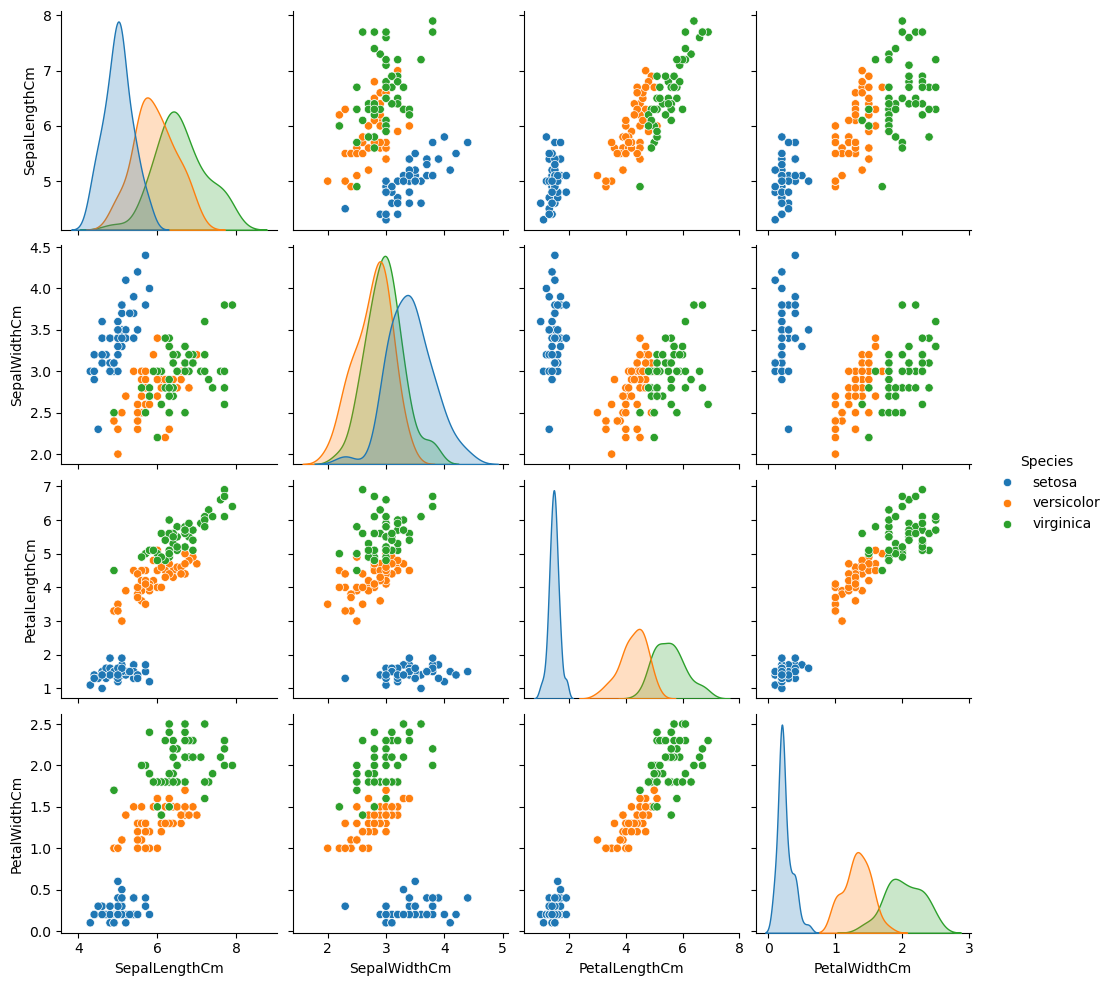

In [13]:
sns.pairplot(iris_df, hue='Species')
plt.savefig("exercise2a.png")
plt.show()

In [9]:
X = iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 
             'PetalWidthCm']].values

y = iris_df['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=1
)

In [10]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

In [11]:
prediction = clf.predict(X_test)
prediction

array(['setosa', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'versicolor', 'virginica', 'setosa', 'setosa', 'virginica',
       'versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor'],
      dtype=object)

In [12]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         6
   virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



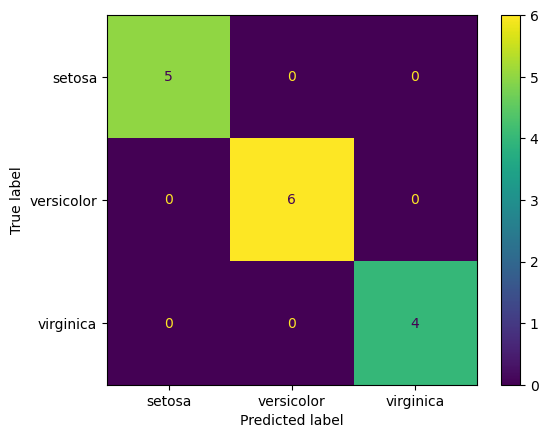

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.savefig("exercise2b.png")
plt.show()

In [26]:
!pip install pydotplus

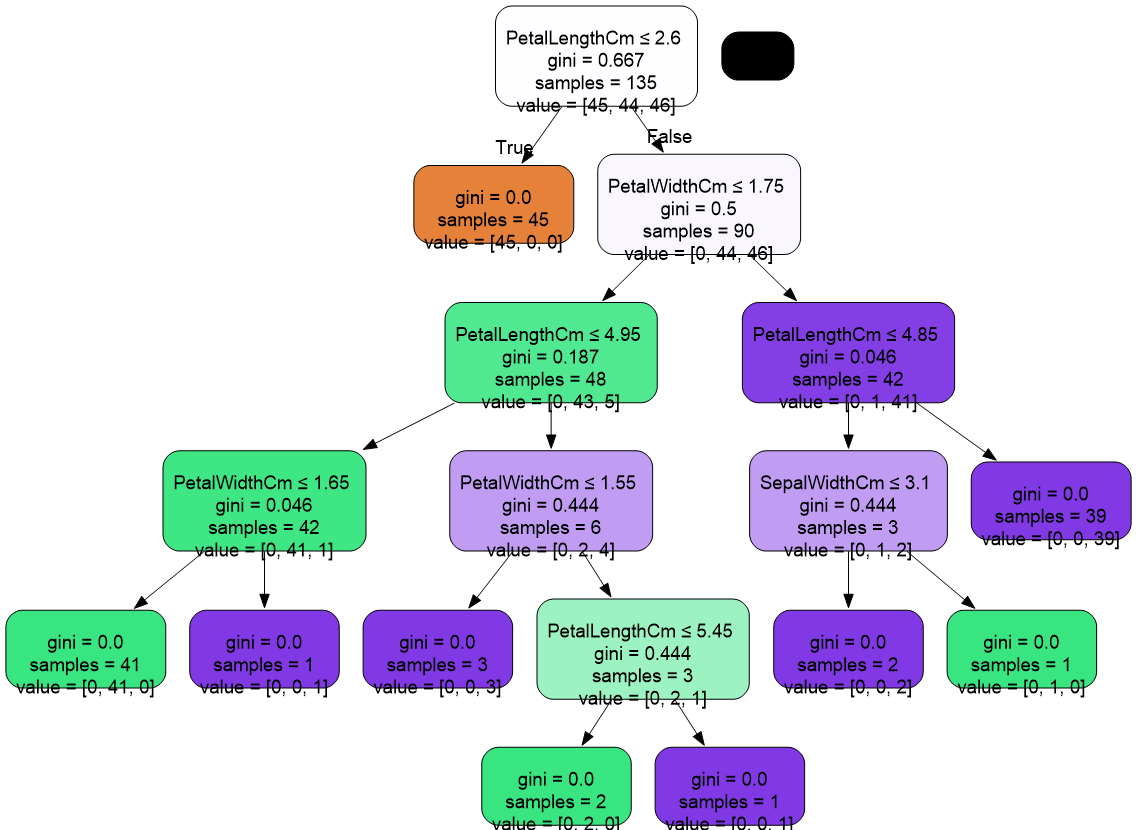

In [14]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

# Visualize the graph
dot_data = StringIO()

export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=['SepalLengthCm', 
                   'SepalWidthCm', 
                   'PetalLengthCm', 
                   'PetalWidthCm'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

Image(graph.create_png())

In [15]:
SepalLengthCm = 4.8
SepalWidthCm = 2.9
PetalLengthCm = 1.3
PetalWidthCm = 0.2

x = [[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]]

res = clf.predict(x)

print("The class predicted is --> " + str(*res))

The class predicted is --> setosa
